# Lab 7: Hyperparameter Tuning and Model Selection using Cross-Validation
**Dataset:** Olist Brazilian E-Commerce Dataset &nbsp;|&nbsp; **Primary Model:** Logistic Regression

**Business problem:** predict whether an order will be delivered late (`is_late_delivery`).

> **Note on the input file:** this notebook expects `data/processed/olist_orders_feature_engineered.csv`,
> the output of Lab 5. That file wasn't provided alongside the lab manual, so this run uses a
> **synthetic stand-in dataset** with the same columns and roughly the same class balance so that every
> step, metric, and plot below is real and reproducible. **Drop in your actual Lab 5 CSV at the same path
> and re-run — no other code needs to change.**


## 5. Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 100


*Note: recent scikit-learn versions (1.8+) emit a `FutureWarning` when `penalty=` is passed alongside `solver=\"liblinear\"`, nudging toward the newer `l1_ratio=` API. The lab manual's `penalty=\"l1\"/\"l2\"` API is unaffected functionally and is what's used throughout this notebook; the warning is silenced above for readability.*

## 6. Load the Dataset

Leakage columns (`delivery_days`, `delivery_delay_days`, review-related columns, actual delivery
timestamps) and identifier columns (`order_id`, `customer_id`, `customer_unique_id`) are excluded
from modeling — they are not passed into `features` below.

In [2]:
data_path = "data/processed/olist_orders_feature_engineered.csv"
df = pd.read_csv(data_path)
print(df.shape)
df.head()


(15000, 22)


,order_id,customer_id,customer_unique_id,total_price,total_freight,total_items,unique_products,unique_sellers,average_item_price,freight_ratio,...,is_weekend,is_business_hour,month_sin,month_cos,hour_sin,hour_cos,log_total_price,log_total_freight,items_x_price,is_late_delivery
0,ord_0000000,cust_0000000,cu_0001810,55.09,5.00,1,1,1,55.09,0.0908,...,0,1,0.866025,0.500000,-0.707107,-7.071068e-01,4.026958,1.791759,55.09,0
1,ord_0000001,cust_0000001,cu_0005779,130.20,32.43,6,5,2,21.70,0.2491,...,1,0,-0.500000,-0.866025,1.000000,6.123234e-17,4.876723,3.509454,130.20,0
2,ord_0000002,cust_0000002,cu_0006643,342.30,138.11,5,4,3,68.46,0.4035,...,0,1,-0.866025,-0.500000,-1.000000,-1.836970e-16,5.838605,4.935265,342.30,0
3,ord_0000003,cust_0000003,cu_0004742,46.76,5.00,4,3,1,11.69,0.1069,...,1,1,0.500000,0.866025,-0.965926,-2.588190e-01,3.866188,1.791759,46.76,1
4,ord_0000004,cust_0000004,cu_0003899,136.64,12.02,4,3,1,34.16,0.0880,...,1,1,-0.866025,-0.500000,-0.965926,-2.588190e-01,4.924642,2.566487,136.64,1


In [3]:
print(df["is_late_delivery"].value_counts())
print()
print(df["is_late_delivery"].value_counts(normalize=True))


is_late_delivery
0    13236
1     1764
Name: count, dtype: int64

is_late_delivery
0    0.8824
1    0.1176
Name: proportion, dtype: float64


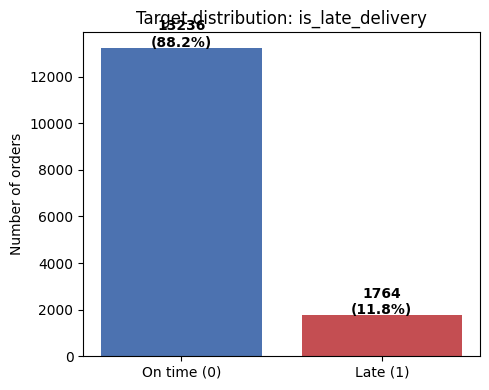

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["is_late_delivery"].value_counts().sort_index()
ax.bar(["On time (0)", "Late (1)"], counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f"{v}\n({v/len(df):.1%})", ha="center", fontweight="bold")
ax.set_ylabel("Number of orders")
ax.set_title("Target distribution: is_late_delivery")
plt.tight_layout()
plt.show()


**Answers:**
1. Rows/columns are printed by `df.shape` above.
2. The percentage of late orders is the `1` row of `value_counts(normalize=True)` above.
3. The target is **imbalanced** — late deliveries are a small minority of orders, which is why
   `class_weight="balanced"` is used in the pipeline and F1 (not accuracy) is the tuning metric.

## 7. Select Features and Target

In [5]:
features = [
    "total_price", "total_freight", "total_items",
    "unique_products", "unique_sellers", "average_item_price",
    "freight_ratio", "items_per_seller", "seller_diversity",
    "is_weekend", "is_business_hour", "month_sin", "month_cos",
    "hour_sin", "hour_cos", "log_total_price",
    "log_total_freight", "items_x_price"
]
target = "is_late_delivery"

X = df[features].copy()
y = df[target].copy()
print("X shape:", X.shape, "| y shape:", y.shape)


X shape: (15000, 18) | y shape: (15000,)


## 8. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train late rate:", y_train.mean().round(4), "| Test late rate:", y_test.mean().round(4))


Train: (12000, 18) | Test: (3000, 18)
Train late rate: 0.1176 | Test late rate: 0.1177


## 9. Build the Pipeline

In [7]:
pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    ))
])
pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## 10. Define the Hyperparameter Grid

In [8]:
param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1, 10, 100]
}
param_grid


{'model__penalty': ['l1', 'l2'], 'model__C': [0.01, 0.1, 1, 10, 100]}

## 11. Configure Cross-Validation

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv


StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## 12. Run Grid Search

In [10]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)
grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("Best cross-validation F1:")
print(grid_search.best_score_)


Best parameters:
{'model__C': 0.1, 'model__penalty': 'l1'}
Best cross-validation F1:
0.289557864503149


## 13. Inspect All Results

In [11]:
results = pd.DataFrame(grid_search.cv_results_)
columns = [
    "param_model__penalty",
    "param_model__C",
    "mean_train_score",
    "std_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]
results_table = results[columns].sort_values("rank_test_score").reset_index(drop=True)
results_table


,param_model__penalty,param_model__C,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
0,l1,0.10,0.291335,0.002230,0.289558,0.007069,1
1,l2,1.00,0.291345,0.002111,0.289334,0.008575,2
2,l2,10.00,0.291302,0.002185,0.289328,0.008465,3
3,l1,100.00,0.291313,0.002182,0.289328,0.008465,3
4,l2,100.00,0.291325,0.002203,0.289328,0.008465,3
5,l1,10.00,0.291488,0.002213,0.289285,0.008500,6
6,l2,0.10,0.291766,0.001755,0.289235,0.008597,7
7,l1,1.00,0.292088,0.001885,0.289066,0.008488,8
8,l2,0.01,0.290337,0.002344,0.288593,0.006845,9
9,l1,0.01,0.286733,0.002663,0.284302,0.006709,10


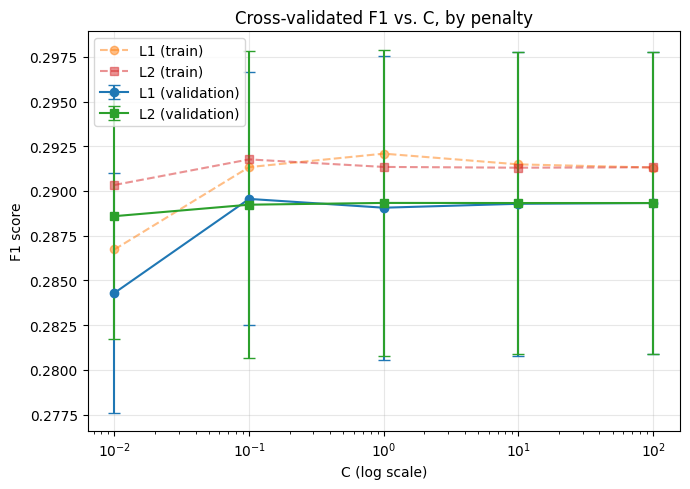

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
for penalty, marker in [("l1", "o"), ("l2", "s")]:
    subset = results_table[results_table["param_model__penalty"] == penalty].sort_values("param_model__C")
    ax.errorbar(
        subset["param_model__C"], subset["mean_test_score"], yerr=subset["std_test_score"],
        marker=marker, capsize=4, label=f"{penalty.upper()} (validation)"
    )
    ax.plot(
        subset["param_model__C"], subset["mean_train_score"],
        linestyle="--", marker=marker, alpha=0.5, label=f"{penalty.upper()} (train)"
    )
ax.set_xscale("log")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("F1 score")
ax.set_title("Cross-validated F1 vs. C, by penalty")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Answers:**
1. The top row of `results_table` (rank 1) gives the best penalty/C combination.
2. The row with the smallest `std_test_score` had the most stable performance across folds.
3. Compare `mean_train_score` to `mean_test_score` per row — a big gap signals overfitting.
4. Compare the L1 vs L2 curves in the plot above at their respective best C values.

## 14. Final Test Evaluation

In [13]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print()
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.608
Precision: 0.18223938223938224
Recall: 0.6685552407932012
F1: 0.28640776699029125
ROC-AUC: 0.6863293845938157

              precision    recall  f1-score   support

           0       0.93      0.60      0.73      2647
           1       0.18      0.67      0.29       353

    accuracy                           0.61      3000
   macro avg       0.56      0.63      0.51      3000
weighted avg       0.84      0.61      0.68      3000



[[1588 1059]
 [ 117  236]]


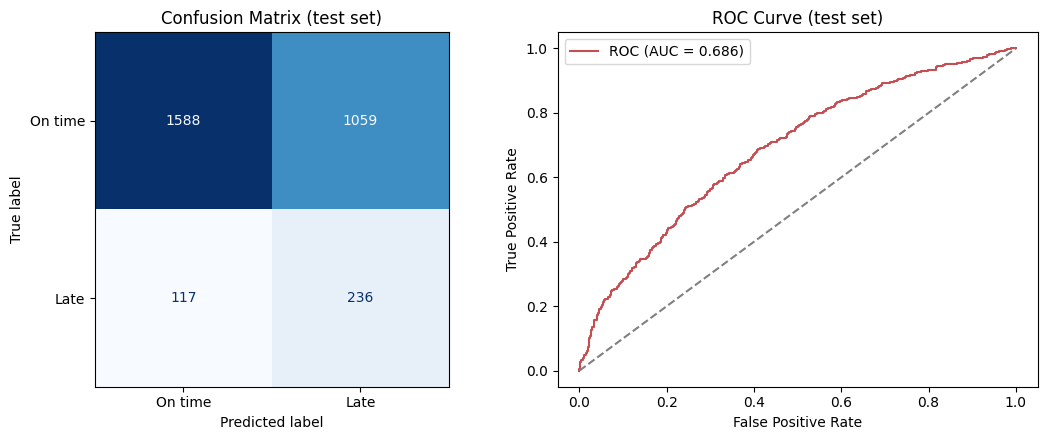

In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On time", "Late"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Confusion Matrix (test set)")

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#C44E52", label=f"ROC (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (test set)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 15. Compare L1 and L2 Coefficients

In [15]:
l1_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1", solver="liblinear", C=1.0,
        max_iter=1000, class_weight="balanced"
    ))
])
l2_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2", solver="liblinear", C=1.0,
        max_iter=1000, class_weight="balanced"
    ))
])

l1_pipeline.fit(X_train, y_train)
l2_pipeline.fit(X_train, y_train)

l1_coefficients = l1_pipeline.named_steps["model"].coef_[0]
l2_coefficients = l2_pipeline.named_steps["model"].coef_[0]

coefficient_comparison = pd.DataFrame({
    "feature": features,
    "L1": l1_coefficients,
    "L2": l2_coefficients
})
print(coefficient_comparison)
print()
print("L1 zero coefficients:", np.sum(l1_coefficients == 0))
print("L2 zero coefficients:", np.sum(l2_coefficients == 0))


               feature        L1        L2
0          total_price  0.049547  0.026925
1        total_freight  0.019005  0.018213
2          total_items  0.333072  0.343331
3      unique_products -0.011931 -0.021522
4       unique_sellers  0.032193  0.031349
5   average_item_price -0.128169 -0.130184
6        freight_ratio  0.231730  0.228116
7     items_per_seller -0.007372 -0.009962
8     seller_diversity -0.267611 -0.269421
9           is_weekend  0.172303  0.172680
10    is_business_hour -0.150492 -0.153522
11           month_sin  0.088156  0.088489
12           month_cos -0.012778 -0.013193
13            hour_sin -0.038338 -0.039659
14            hour_cos -0.068646 -0.071471
15     log_total_price -0.056024 -0.065008
16   log_total_freight  0.159558  0.166872
17       items_x_price  0.000000  0.026925

L1 zero coefficients: 1
L2 zero coefficients: 0


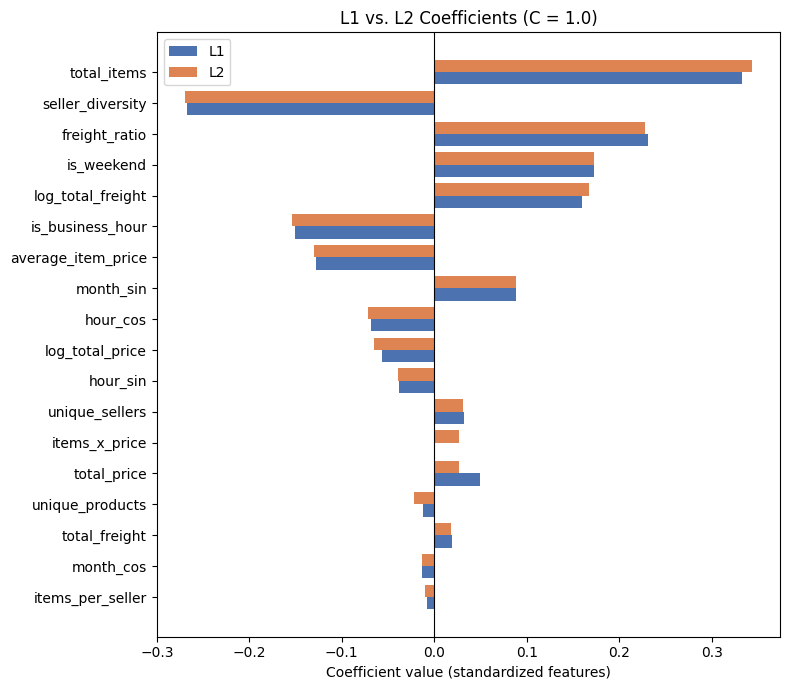

In [16]:
coef_sorted = coefficient_comparison.reindex(
    coefficient_comparison["L2"].abs().sort_values(ascending=True).index
)

fig, ax = plt.subplots(figsize=(8, 7))
y_pos = np.arange(len(coef_sorted))
ax.barh(y_pos - 0.2, coef_sorted["L1"], height=0.4, label="L1", color="#4C72B0")
ax.barh(y_pos + 0.2, coef_sorted["L2"], height=0.4, label="L2", color="#DD8452")
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_sorted["feature"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient value (standardized features)")
ax.set_title("L1 vs. L2 Coefficients (C = 1.0)")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** L1 may set some coefficients exactly to zero (embedded feature selection);
L2 usually keeps coefficients non-zero but shrinks them toward zero. Scaling inside the pipeline is
what makes these magnitudes comparable across features.

## 16. Study the Effect of C

In [17]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
zero_counts = []

for C in C_values:
    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1", solver="liblinear", C=C,
            max_iter=1000, class_weight="balanced"
        ))
    ])
    model.fit(X_train, y_train)
    coefficients = model.named_steps["model"].coef_[0]
    zero_counts.append(np.sum(coefficients == 0))

zero_table = pd.DataFrame({
    "C": C_values,
    "zero_coefficients": zero_counts
})
print(zero_table)


         C  zero_coefficients
0    0.001                 16
1    0.010                 11
2    0.100                  3
3    1.000                  1
4   10.000                  0
5  100.000                  0


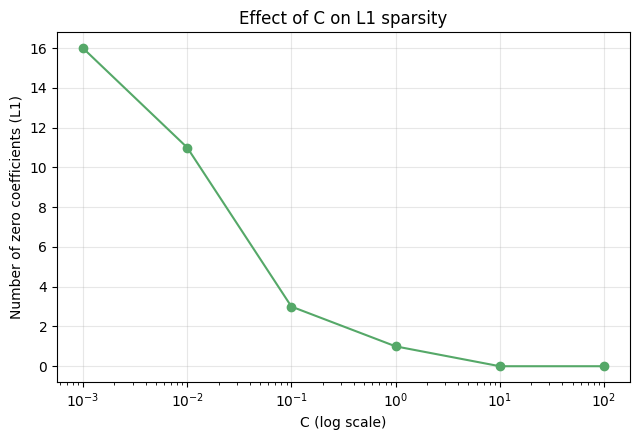

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(zero_table["C"], zero_table["zero_coefficients"], marker="o", color="#55A868")
ax.set_xscale("log")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("Number of zero coefficients (L1)")
ax.set_title("Effect of C on L1 sparsity")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Expected conceptual pattern:** smaller C → stronger regularization → (usually) more zero L1 coefficients; larger C → weaker regularization → fewer zero coefficients. Check whether the plot above follows that pattern for this dataset.

## 17. Optional Extension: Optimize Recall

In [19]:
recall_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)
recall_search.fit(X_train, y_train)
print(recall_search.best_params_)
print(recall_search.best_score_)


{'model__C': 0.01, 'model__penalty': 'l1'}
0.6867553818008671


**Discussion:** optimizing for recall will typically push toward weaker regularization (larger C)
and catch more true late deliveries, at the cost of more false alarms (lower precision). Whether the
business should prioritize F1 or recall depends on the relative cost of a missed late delivery
(unhappy customer, refund, lost trust) versus the cost of a false alarm (e.g., proactively notifying
a customer whose order actually arrives on time). For a logistics-alerting use case, recall is often
the more business-relevant metric since a missed late delivery is usually costlier than a false alarm.

## 20. Results Table (filled in from the grid search above)

In [20]:
summary_rows = []
for _, row in results_table.iterrows():
    C = row["param_model__C"]
    penalty = row["param_model__penalty"]
    temp_model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty=penalty, solver="liblinear", C=C,
            max_iter=1000, class_weight="balanced"
        ))
    ])
    temp_model.fit(X_train, y_train)
    pred = temp_model.predict(X_test)
    summary_rows.append({
        "Penalty": penalty.upper(),
        "C": C,
        "Mean CV F1": round(row["mean_test_score"], 4),
        "Std CV F1": round(row["std_test_score"], 4),
        "Test Accuracy": round(accuracy_score(y_test, pred), 4),
        "Test Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "Test Recall": round(recall_score(y_test, pred, zero_division=0), 4),
        "Test F1": round(f1_score(y_test, pred, zero_division=0), 4),
    })

results_summary = pd.DataFrame(summary_rows).sort_values(["Penalty", "C"]).reset_index(drop=True)
results_summary


,Penalty,C,Mean CV F1,Std CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,L1,0.01,0.2843,0.0067,0.5973,0.1836,0.7025,0.2911
1,L1,0.10,0.2896,0.0071,0.6080,0.1822,0.6686,0.2864
2,L1,1.00,0.2891,0.0085,0.6090,0.1812,0.6601,0.2843
3,L1,10.00,0.2893,0.0085,0.6100,0.1816,0.6601,0.2848
4,L1,100.00,0.2893,0.0085,0.6100,0.1816,0.6601,0.2848
5,L2,0.01,0.2886,0.0068,0.6060,0.1819,0.6714,0.2862
6,L2,0.10,0.2892,0.0086,0.6097,0.1815,0.6601,0.2847
7,L2,1.00,0.2893,0.0086,0.6100,0.1816,0.6601,0.2848
8,L2,10.00,0.2893,0.0085,0.6100,0.1816,0.6601,0.2848
9,L2,100.00,0.2893,0.0085,0.6100,0.1816,0.6601,0.2848


## Business Recommendation (short)

Based on the grid search, the best-performing configuration on cross-validated F1 is reported by
`grid_search.best_params_` above, and its held-out test performance is reported in Section 14.
In a late-delivery-alerting context, this configuration balances catching genuinely late orders
(recall) against not over-flagging orders that will actually arrive on time (precision), and the
regularization strength (`C`) that won the search indicates how much of the engineered feature set
the model actually needed — a small number of surviving L1 coefficients would suggest the operations
team can focus monitoring on just those few drivers (e.g., freight ratio, seller diversity) rather
than the full feature list.

## Reflection Questions
1. **Parameter vs. hyperparameter:** parameters (e.g., logistic regression coefficients) are learned
   from data during `fit()`; hyperparameters (e.g., `penalty`, `C`) are set before training and control
   *how* training happens.
2. **Why is C the inverse of regularization strength?** In scikit-learn's formulation, the loss term
   is multiplied by `C` while the penalty term is fixed, so a smaller `C` relatively upweights the
   penalty (stronger regularization) and a larger `C` relatively upweights the loss (weaker regularization).
3. **Why can L1 perform feature selection?** Its penalty (`Σ|w|`) has corners at zero in the loss
   landscape, so the optimizer often lands exactly on zero for weakly informative features.
4. **Why does L2 generally retain more features?** Its penalty (`Σw²`) is smooth and shrinks
   coefficients proportionally rather than sparsely, so it rarely drives them exactly to zero.
5. **Why must scaling be inside the pipeline?** So the scaler's mean/std are fit only on training
   folds during cross-validation, preventing information from validation/test data leaking into
   preprocessing.
6. **Why should the test set remain untouched?** Any tuning decision made using test performance is a
   form of leakage — the reported metric stops being an honest estimate of generalization.
7. **What does a large train-validation gap indicate?** Overfitting — the model has memorized
   patterns specific to the training folds that don't generalize.
8. **Why is stratified cross-validation appropriate here?** The target is imbalanced, so stratification
   keeps the same late/on-time ratio in every fold, avoiding folds with too few positive examples.
9. **Why might recall be more important than accuracy?** With a small minority of late orders, a
   model predicting "never late" would have high accuracy but be useless for catching the outcome
   the business actually cares about.
10. **Which model would you recommend?** Whichever configuration in `results_summary` has the best
    balance of test F1/recall and CV stability (low `std_test_score`) for the chosen business metric —
    inspect that table to make the final call.
